In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("float.csv", encoding='utf-16', engine='python')
df.head()

,T,N,inf,analytical,naive,half_recursion,double_step,kahan
0,0.1,10,100.0,0.178412,0.000000,0.000000,0.000000,0.000000
1,0.1,100,100.0,0.178412,0.000162,0.000162,0.000162,0.146450
2,0.1,1000,100.0,0.178412,0.175408,0.175408,0.175408,0.179926
3,0.1,10000,100.0,0.178412,0.178383,0.178383,0.178383,0.178427
4,0.1,100000,100.0,0.178412,0.178412,0.178412,0.178412,0.178413


In [3]:
'''new_df
T,      N,      type,       error,
0.1,    10,     naive,      100,
0.1,    10,     half_recursion,      89,
'''

'new_df\nT,      N,      type,       error,\n0.1,    10,     naive,      100,\n0.1,    10,     half_recursion,      89,\n'

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


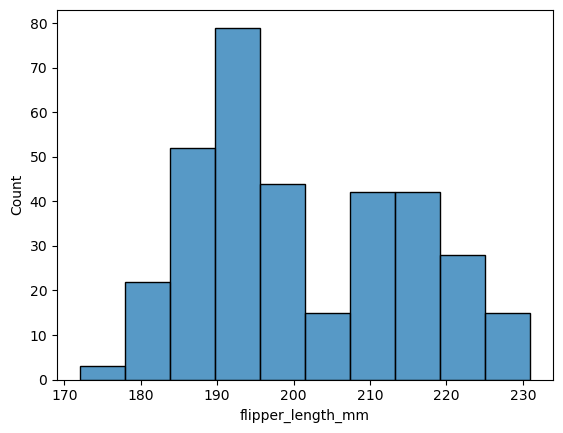

In [4]:
penguins = sns.load_dataset("penguins")
sns.histplot(data=penguins, x="flipper_length_mm")
penguins.head()

# График для сдачи:
- столбчатая диаграмма, 
    - по оси абсцисс температуры/*количество* точек, 
    - разноцветные столбики (цвет соответствует методу) 
    - высота столбика определяется относительной ошибкой 
    
        (полученное / аналитический ответ - 1) * 100

<Axes: xlabel='N', ylabel='Count'>

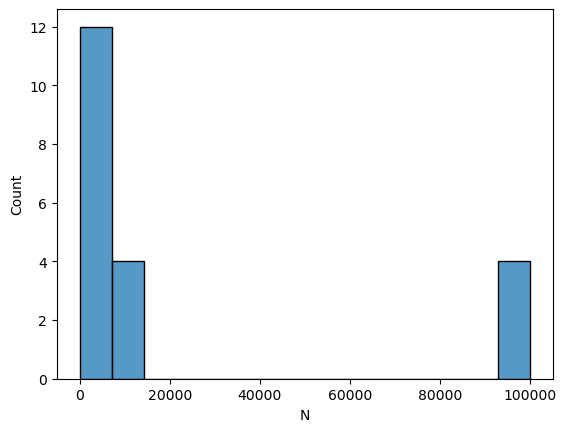

In [5]:
cols = ['naive', 'half_recursion', 'double_step', 'kahan']

# sns.histplot(data=df, x="T", hue="species")
sns.histplot(data=df, x='N')

In [6]:
df = pd.read_csv("float.csv", encoding='utf-16', engine='python')
df.head()

,T,N,inf,analytical,naive,half_recursion,double_step,kahan
0,0.1,10,100.0,0.178412,0.000000,0.000000,0.000000,0.000000
1,0.1,100,100.0,0.178412,0.000162,0.000162,0.000162,0.146450
2,0.1,1000,100.0,0.178412,0.175408,0.175408,0.175408,0.179926
3,0.1,10000,100.0,0.178412,0.178383,0.178383,0.178383,0.178427
4,0.1,100000,100.0,0.178412,0.178412,0.178412,0.178412,0.178413


In [7]:
'''new_df
T,      N,      type,           error,
0.1,    10,     naive,          100,
0.1,    10,     half_recursion, 89,
'''

'new_df\nT,      N,      type,           error,\n0.1,    10,     naive,          100,\n0.1,    10,     half_recursion, 89,\n'

In [8]:
hdf = pd.DataFrame(columns=['T', 'N', 'type', 'error'])
print(df.index)
for idx, row in df.iterrows():
    for col in df.columns[4:]:
        hdf.loc[len(hdf)] = [row['T'], row['N'], col, 100*(row[col]-row['analytical'])/row['analytical']]
# hdf.head()
hdf['logN'] = np.log10(hdf['N'])
hdf['logT'] = np.log10(hdf['T'])
hdf


RangeIndex(start=0, stop=20, step=1)


,T,N,type,error,logN,logT
0,0.1,10.0,naive,-100.000000,1.0,-1.0
1,0.1,10.0,half_recursion,-100.000000,1.0,-1.0
2,0.1,10.0,double_step,-100.000000,1.0,-1.0
3,0.1,10.0,kahan,-100.000000,1.0,-1.0
4,0.1,100.0,naive,-99.909200,2.0,-1.0
...,...,...,...,...,...,...
75,10000.0,10000.0,kahan,0.000000,4.0,4.0
76,10000.0,100000.0,naive,-0.004699,5.0,4.0
77,10000.0,100000.0,half_recursion,0.000000,5.0,4.0
78,10000.0,100000.0,double_step,0.000007,5.0,4.0


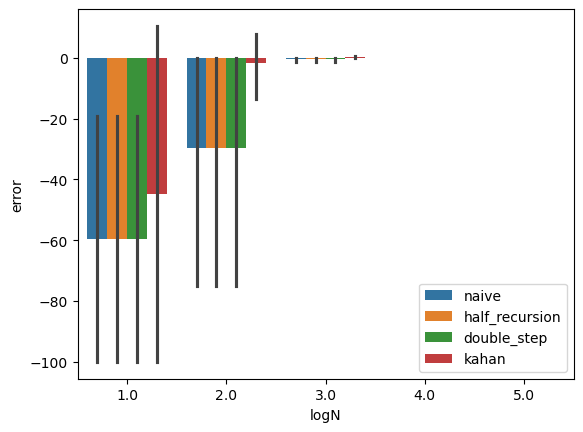

In [9]:
sns.barplot(data=hdf, x="logN", y="error", hue="type")

plt.legend()
plt.show()

## Графики от N

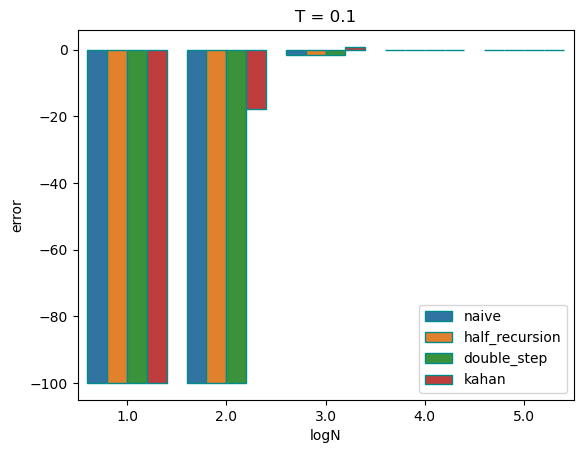

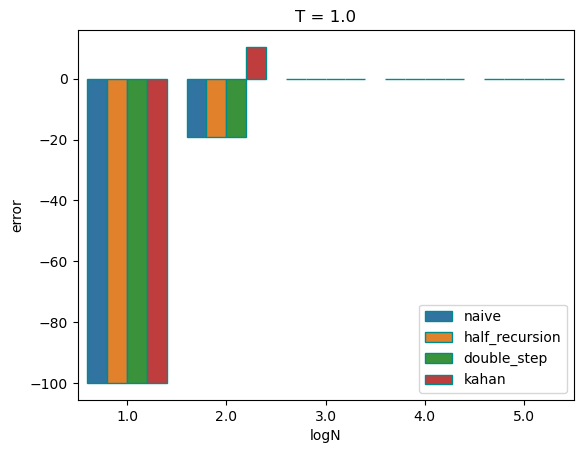

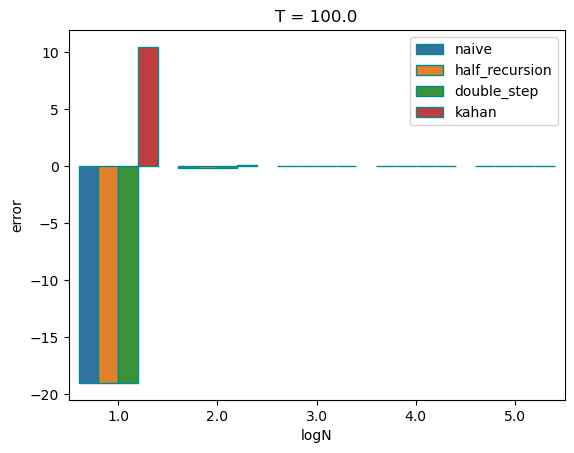

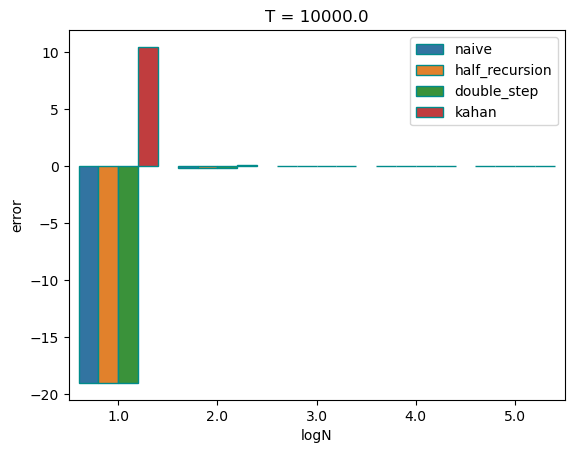

In [10]:
for n in hdf['T'].unique():
    sns.barplot(data=hdf[hdf['T'] == n], x="logN", y="error", hue="type", errorbar=None, linewidth=1, edgecolor="darkcyan")
    plt.legend()
    plt.title(f'T = {n}')
    plt.show()

## Графики от T

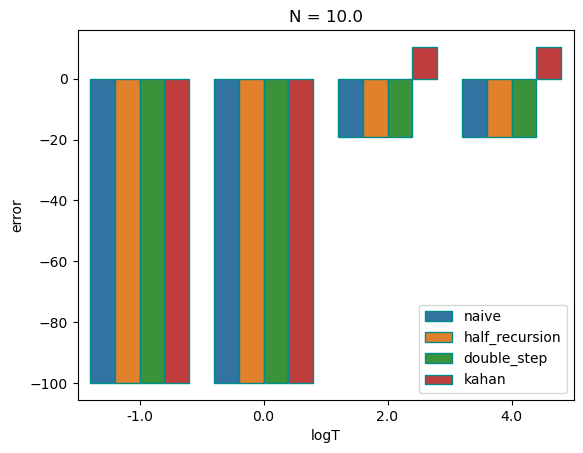

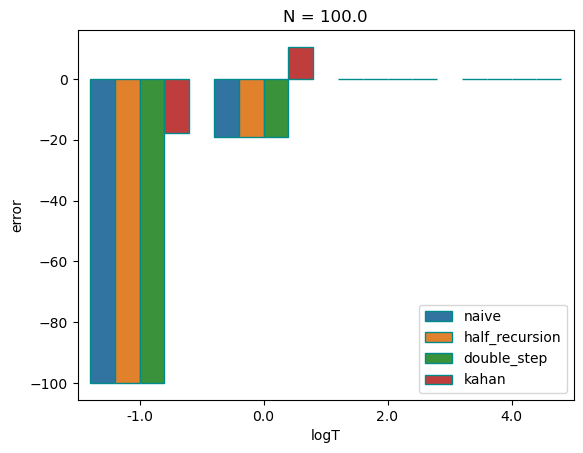

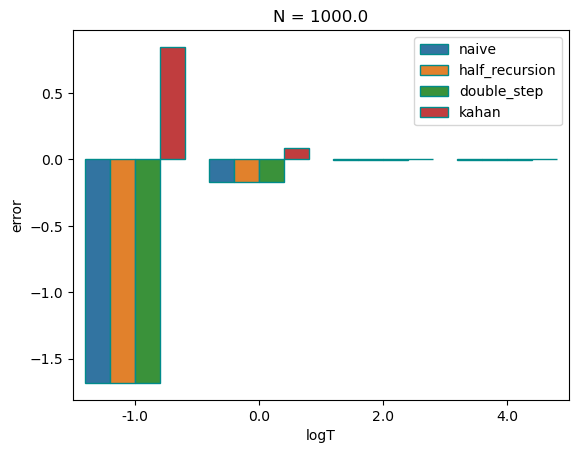

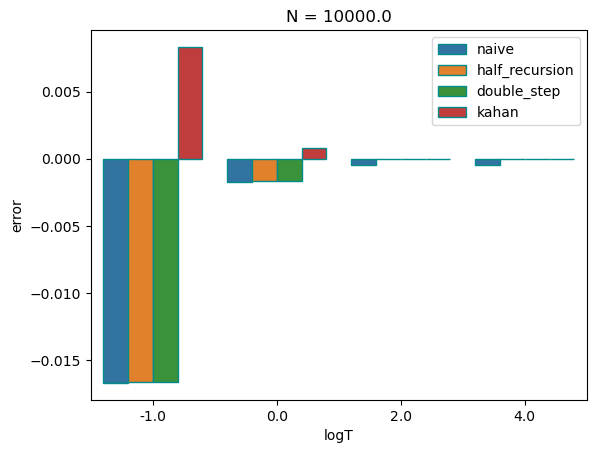

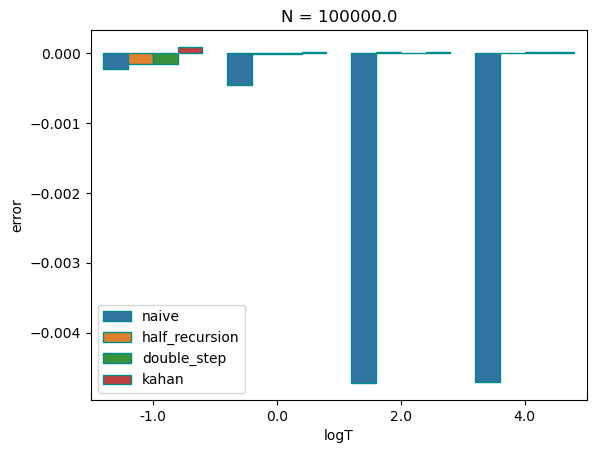

In [11]:
for n in hdf['N'].unique():
    sns.barplot(data=hdf[hdf['N'] == n], x="logT", y="error", hue="type", errorbar=None, linewidth=1, edgecolor="darkcyan")
    plt.legend()
    plt.title(f'N = {n}')
    plt.show()